## Multi Modal News Analyzer

### Part 1
#### Data Collection and Preparation
- Text Cleaning
- Tokenization
- Stop Word Removal
- Lemmatization

In [1]:
# --- 1. Setup and Imports ---
import pandas as pd
import torch
import numpy as np
import re
import string
import seaborn as sns
import matplotlib.pyplot as plt

# Sklearn for metrics and data splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Hugging Face Transformers
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding

# NLTK for text preprocessing
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# --- NLTK Downloads ---
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')


# --- Environment Setup ---
# Set up device (GPU/CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Mount Google Drive (if your file is stored there)
from google.colab import drive
drive.mount('/content/gdrive')


# --- Data Loading ---
file_path = '/content/gdrive/MyDrive/News_Category_Dataset_v3.json'
df = pd.read_json(file_path, lines=True)

print(f"\nTotal data points: {len(df)}")
print("\nFirst 5 rows:")
print(df.head())
print("\nCategory distribution (Top 10):")
print(df['category'].value_counts().head(10))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


Using device: cpu
Mounted at /content/gdrive

Total data points: 209527

First 5 rows:
                                                link  \
0  https://www.huffpost.com/entry/covid-boosters-...   
1  https://www.huffpost.com/entry/american-airlin...   
2  https://www.huffpost.com/entry/funniest-tweets...   
3  https://www.huffpost.com/entry/funniest-parent...   
4  https://www.huffpost.com/entry/amy-cooper-lose...   

                                            headline   category  \
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS   
1  American Airlines Flyer Charged, Banned For Li...  U.S. NEWS   
2  23 Of The Funniest Tweets About Cats And Dogs ...     COMEDY   
3  The Funniest Tweets From Parents This Week (Se...  PARENTING   
4  Woman Who Called Cops On Black Bird-Watcher Lo...  U.S. NEWS   

                                   short_description               authors  \
0  Health experts said it is too early to predict...  Carla K. Johnson, AP   
1  He was subdued

In [2]:
#Check for missing values

print("\n Missing values per column:")
print(df.isnull().sum())

#Check distribution of categories

print(df['category'].value_counts())

print("\n Example headlines and descriptions:")
print(df[['headline', 'short_description', 'category']].sample(5))


 Missing values per column:
link                 0
headline             0
category             0
short_description    0
authors              0
date                 0
dtype: int64
category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
COMEDY             5400
SPORTS             5077
BLACK VOICES       4583
HOME & LIVING      4320
PARENTS            3955
THE WORLDPOST      3664
WEDDINGS           3653
WOMEN              3572
CRIME              3562
IMPACT             3484
DIVORCE            3426
WORLD NEWS         3299
MEDIA              2944
WEIRD NEWS         2777
GREEN              2622
WORLDPOST          2579
RELIGION           2577
STYLE              2254
SCIENCE            2206
TECH               2104
TASTE              2096
MONEY              1756
ARTS               1509
ENVIRONMENT        

In [3]:
#Function to clean the text

stop_words = set(stopwords.words('english'))
def clean_text(text):
    #convert to lowercase
    text=text.lower()

    #remove URLs
    text= re.sub(r'https?:\S*|www\.S*','',text)

    #remove punctuation and special characters
    text=text.translate(str.maketrans('','', string.punctuation))

    #remove stop words
    words=text.split()
    filtered_words=[word for word in words if word not in stop_words]
    # join the words back into a string
    text=" ".join(filtered_words)

    return text


In [4]:
df['combined_text'] = df['headline'] + " " + df['short_description']

In [5]:
df['combined_text']=df['combined_text'].apply(clean_text)

In [6]:
#function for lemmatising text with nltk

lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ  # Adjective
    elif tag.startswith('V'):
        return wordnet.VERB  # Verb
    elif tag.startswith('N'):
        return wordnet.NOUN  # Noun
    elif tag.startswith('R'):
        return wordnet.ADV  # Adverb
    else:
        return wordnet.NOUN # Default to Noun

def tokenize_and_lemmatize(text):
    tokens = word_tokenize(text)
    tagged_words = nltk.pos_tag(tokens)
    lemmatized_words = []
    for word, tag in tagged_words:
        w_pos = get_wordnet_pos(tag)
        lemma = lemmatizer.lemmatize(word, pos=w_pos)
        lemmatized_words.append(lemma)

    return " ".join(lemmatized_words)



In [7]:
df['lemmatized_combined_text']=df['combined_text'].apply(tokenize_and_lemmatize)

In [8]:
print(df['lemmatized_combined_text'].head())

0    4 million american roll sleeve omicrontargeted...
1    american airline flyer charge ban life punch f...
2    23 funny tweet cat dog week sept 1723 dog dont...
3    funny tweet parent week sept 1723 accidentally...
4    woman call cop black birdwatcher lose lawsuit ...
Name: lemmatized_combined_text, dtype: object


Topic Classification

In [9]:
le= LabelEncoder()

# Fit the encoder to your categories and transform them
df['category_id'] = le.fit_transform(df['category'])

# Verify the number of classes and an example mapping
num_classes = len(le.classes_)
print(f"Total Number of Classes: {num_classes}")
print(f"Category IDs (e.g.): {df[['category', 'category_id']].drop_duplicates().head()}")


Total Number of Classes: 42
Category IDs (e.g.):          category  category_id
0       U.S. NEWS           35
2          COMEDY            5
3       PARENTING           22
7      WORLD NEWS           40
8  CULTURE & ARTS            7


In [10]:

tokenizer=AutoTokenizer.from_pretrained('bert-base-uncased')

def encode_texts(texts, max_length=128):
    """ Tokenizes and encodes a list of texts using the Transformer tokenizer. """
    text_list = [str(t) for t in texts.tolist()]

    return tokenizer.batch_encode_plus(
        texts.tolist(),
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_token_type_ids=False,
        return_tensors='pt'
    )
encoded_data= encode_texts(df['lemmatized_combined_text'])

input_ids= encoded_data['input_ids']
attention_masks=encoded_data['attention_mask']
labels=torch.tensor(df['category_id'].values)

print(f"\nShape of Input IDs: {input_ids.shape}")
print(f"Shape of Attention Masks: {attention_masks.shape}")
print(f"Shape of Labels: {labels.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]


Shape of Input IDs: torch.Size([209527, 128])
Shape of Attention Masks: torch.Size([209527, 128])
Shape of Labels: torch.Size([209527])


Split Data and Create DataLoaders

In [12]:
from torch.utils.data import Dataset, DataLoader, random_split

class NewsCategoryDataset(Dataset):
    def __init__(self, input_ids, attention_masks, labels):
        self.input_ids = input_ids
        self.attention_masks = attention_masks
        self.labels = labels

    def __len__(self):
        return len(self.labels)
    # The commented-out section was correctly indented. The active __getitem__ was over-indented.
    # I've corrected the indentation for the active __getitem__ method.
    def __getitem__(self, idx):
        return {
            'input_ids': self.input_ids[idx].clone().detach(),  # Convert to Python ints
            'attention_mask': self.attention_masks[idx].clone().detach(),
            'labels': self.labels[idx].item()  # Convert to Python int
        }

dataset = NewsCategoryDataset(input_ids, attention_masks, labels)

# determine the size of the training set

train_size= int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

print( "Training set size: " , len(train_dataset))
print( "Validation set size: ", len(val_dataset))

batch_size = 32

train_dataloader = DataLoader(
    train_dataset,
    sampler=torch.utils.data.RandomSampler(train_dataset),
    batch_size=batch_size
)

validation_dataloader = DataLoader(
    val_dataset,
    sampler=torch.utils.data.SequentialSampler(val_dataset),
    batch_size=batch_size
)

print("\nDataLoaders successfully created. Ready for model setup!")

Training set size:  167621
Validation set size:  41906

DataLoaders successfully created. Ready for model setup!


Implement the Training Loop

In [13]:
# Assuming 'train_dataset' is the original 167,621 samples

# Determine the size of the small training subset (e.g., 10% of 167621)
small_train_size = int(0.10 * len(train_dataset))
remaining_size = len(train_dataset) - small_train_size

# Split the original training dataset into a small subset and the remainder
small_train_dataset, _ = torch.utils.data.random_split(
    train_dataset,
    [small_train_size, remaining_size]
)

print(f"New small training set size: {len(small_train_dataset)}")
# New size: ~16,762 samples, which should reduce training time by 90%.

# RE-CREATE THE DATALOADER using the small subset
small_train_dataloader = DataLoader(
    small_train_dataset,
    sampler=torch.utils.data.RandomSampler(small_train_dataset),
    batch_size=32 # Or whatever batch size you choose
)
small_val_size = int(0.10 * len(val_dataset))
remaining_size = len(val_dataset) - small_val_size

# Split the original validation dataset into a small subset and the remainder
small_val_dataset, _ = torch.utils.data.random_split(
    val_dataset,
    [small_val_size, remaining_size]
)

print(f"New small validation set size: {len(small_val_dataset)}")

small_val_dataloader = DataLoader(
    small_val_dataset,
    sampler=torch.utils.data.RandomSampler(small_val_dataset),
    batch_size=32 # Or whatever batch size you choose
)


New small training set size: 16762
New small validation set size: 4190


In [14]:
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=num_classes)


# 1. Define the Compute Metrics Function
def compute_metrics(p):
    """
    Computes accuracy on the validation set.
    'p' is a tuple (predictions, label_ids) returned by the Trainer.
    """
    predictions, labels = p

    # Get the index of the highest probability (the predicted class)
    predictions = np.argmax(predictions, axis=1)

    # Calculate simple accuracy
    return {'accuracy': accuracy_score(labels, predictions)}

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
# 2. Update TrainingArguments
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3, # Increased to 3 epochs for better results
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    logging_dir='./logs',
    logging_steps=100, # Check loss more often

    # === NEW: Evaluation Strategy ===
    eval_strategy="epoch", # Calculate and log validation metrics at the end of every epoch
    save_strategy="epoch",       # Save the model checkpoint at the end of every epoch
    load_best_model_at_end=True, # Load the model that performed best on validation data
)

# 3. Initialize Trainer with the Metrics Function
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=small_train_dataset,
    eval_dataset=small_val_dataset,
    data_collator=data_collator,

    # === NEW: Provide the function to calculate metrics ===
    compute_metrics=compute_metrics,
)

# 4. Train & Evaluate
trainer.train()

# This will print the final evaluation results using the compute_metrics function
results = trainer.evaluate()
print(results)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [23]:

!pip install wandb -q

import wandb


# Initialize W&B (create free account at wandb.ai first)
wandb.init(project="multi-modal-news-analyzer", name="bert-text-classifier")

# Wrap your trainer with W&B logging
from transformers import TrainerCallback

class WandbCallback(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs:
            wandb.log(logs)

# Update your trainer to include the callback
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    logging_dir='./logs',
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="wandb"  # NEW: This sends logs to W&B automatically
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=small_train_dataset,
    eval_dataset=small_val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[WandbCallback()]  # NEW: Add callback
)

eval/accuracy,▁▆█▆
eval/loss,█▁▂▁
eval/runtime,▁▂▂█
eval/samples_per_second,█▇▇▁
eval/steps_per_second,█▇▇▁
train/epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇█████
train/global_step,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
train/grad_norm,▂▃▃▄▃▃▅▅▃▅▄▂▃▃▂▅▃▁▁▃▅▁█▂▄▂▂▃▅▆▆▂▁▅▂▅▄▁▄▃
train/learning_rate,███▇▇▇▇▇▇▇▆▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁
train/loss,█▇▆▆▅▅▅▆▅▅▅▄▅▅▃▃▃▃▃▃▃▃▃▃▃▃▃▁▁▁▁▂▁▁▁▁▁▁▁▁
eval/accuracy,0.61098



=== Detailed Classification Report ===
                precision    recall  f1-score   support

          ARTS       0.22      0.35      0.27        31
ARTS & CULTURE       0.00      0.00      0.00        29
  BLACK VOICES       0.43      0.28      0.34        86
      BUSINESS       0.45      0.57      0.51       127
       COLLEGE       0.33      0.32      0.32        19
        COMEDY       0.48      0.41      0.44       102
         CRIME       0.43      0.85      0.57        74
CULTURE & ARTS       0.45      0.41      0.43        22
       DIVORCE       0.55      0.81      0.66        57
     EDUCATION       0.43      0.43      0.43        23
 ENTERTAINMENT       0.67      0.63      0.65       365
   ENVIRONMENT       0.52      0.39      0.45        28
         FIFTY       0.00      0.00      0.00        33
  FOOD & DRINK       0.67      0.70      0.69       135
     GOOD NEWS       0.36      0.19      0.25        26
         GREEN       0.31      0.38      0.34        55
HEALTHY

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


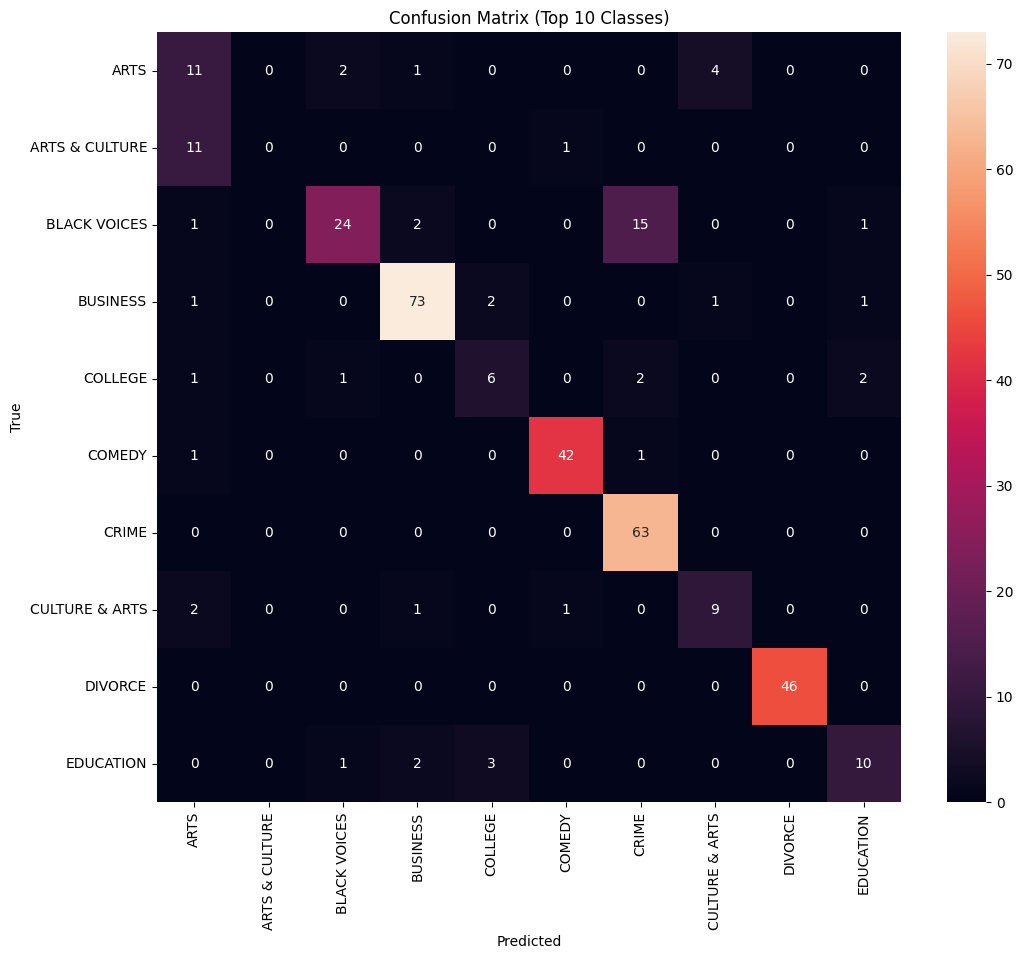

<Figure size 640x480 with 0 Axes>

In [25]:
# NEW CELL: Add after training completes

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions
predictions = trainer.predict(small_val_dataset)
preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

# Detailed classification report
print("\n=== Detailed Classification Report ===")
print(classification_report(labels, preds,
                          target_names=le.classes_))  # Changed label_encoder to le

# Confusion Matrix for top classes
plt.figure(figsize=(12, 10))
cm = confusion_matrix(labels, preds)
# Plot only first 10x10 for readability
sns.heatmap(cm[:10, :10], annot=True, fmt='d',
            xticklabels=le.classes_[:10],
            yticklabels=le.classes_[:10])
plt.title('Confusion Matrix (Top 10 Classes)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Save to W&B
wandb.log({"confusion_matrix": wandb.Image(plt)})

In [28]:
# NEW CELL: Add at the very end

# Save the trained model
model.save_pretrained("./saved_news_classifier")
tokenizer.save_pretrained("./saved_news_classifier")

# Test with a sample news article
sample_news = "Apple announces new iPhone with advanced AI features and improved camera system"
sample_encoding = tokenizer(sample_news, return_tensors='pt',
                           truncation=True, padding=True, max_length=128)

# Move model to appropriate device (CPU or GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Move input tensors to the same device as the model
sample_encoding['input_ids'] = sample_encoding['input_ids'].to(device)
sample_encoding['attention_mask'] = sample_encoding['attention_mask'].to(device)
# Ensure token_type_ids are also moved to the device if they exist
if 'token_type_ids' in sample_encoding:
    sample_encoding['token_type_ids'] = sample_encoding['token_type_ids'].to(device)

with torch.no_grad():
    outputs = model(**sample_encoding)
    prediction = torch.argmax(outputs.logits, dim=1).item()

print(f"\nSample News: {sample_news}")
print(f"Predicted Category: {le.inverse_transform([prediction])[0]}")

# Save sample prediction to W&B
wandb.log({
    "sample_prediction": {
        "text": sample_news,
        "predicted_category": le.inverse_transform([prediction])[0]
    }
})

# Finish W&B run
wandb.finish()


Sample News: Apple announces new iPhone with advanced AI features and improved camera system
Predicted Category: TECH


test/accuracy,▁▁
test/loss,▁▁
test/model_preparation_time,▁▁
test/runtime,█▁
test/samples_per_second,▁█
test/steps_per_second,▁█
train/global_step,▁▁▁▁
test/accuracy,0.61098
test/loss,1.47485
test/model_preparation_time,0.0048
test/runtime,26.4485


In [29]:
# NEW CELL: Add before saving the model
import joblib

# Save the label encoder
joblib.dump(le, "./saved_news_classifier/label_encoder.pkl")
print("Label encoder saved!")

Label encoder saved!
